# Visualization

Trong bài tập này, bạn sẽ được rèn luyện kĩ năng trực quan hóa. Trực quan hóa ngoài việc hỗ  trợ trong khâu tiền xử lí dữ liệu, còn giúp bạn phân tích và rút ra được các thông tin có ý nghĩa từ dữ liệu

**Tập dữ liệu** được sử dụng được lấy từ trang batdongsan.com.vn

In [2]:
#Import các thư viện cần thiết

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings(action='once')
import random
import math

In [3]:
#Load dữ liệu từ file
newdf = pd.read_csv("batdongsan.com.vn.csv", dtype = {"month": "string" , "id" : "string"})
print("DONE")

DONE


In [3]:
newdf.columns

Index(['id', 'month', 'project', 'investor', 'square', 'bedrooms', 'bathrooms',
       'direction', 'balcony', 'district', 'ward', 'price'],
      dtype='str')

In [4]:
# Xem 5 hàng dữ liệu đầu tiên, các thông tin ban đầu: df.info(), df.describe(), ...
# Code ở đây:
newdf.head()

,id,month,project,investor,square,bedrooms,bathrooms,direction,balcony,district,ward,price
0,28086120,12,Vinhomes Smart City Đại Mỗ,Tập đoàn Vingroup,60.0,3.0,1.0,Đông-Nam,Tây-Bắc,nam tu liem,dai mo,1560.0
1,28088954,12,Goldmark City,Công ty TNHH Thương mại - Quảng cáo - Xây dựng...,121.0,3.0,2.0,NaN,NaN,bac tu liem,phu dien,3300.0
2,28097966,12,Chung cư IEC Tứ Hiệp,NaN,70.0,2.0,2.0,Tây-Bắc,Đông-Nam,thanh tri,tu hiep,1106.0
3,27895887,12,Vinhomes D'Capitale,Tân Hoàng Minh Group,39.0,1.0,1.0,Đông-Nam,Đông-Nam,cau giay,trung hoa,1500.0
4,28056031,12,The Zen Residence,Công ty TNHH Gamuda Land Việt Nam,97.0,3.0,2.0,NaN,NaN,hoang mai,hoang liet,2900.0


Đưa ra các câu lệnh để thực hiện các yêu cầu sau:

1. Minh họa boxblot của các trường số như price, bedrooms, square, ...

* Gợi ý: sns.boxplot(data_field)

c:\Users\Lenovo\miniconda3\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


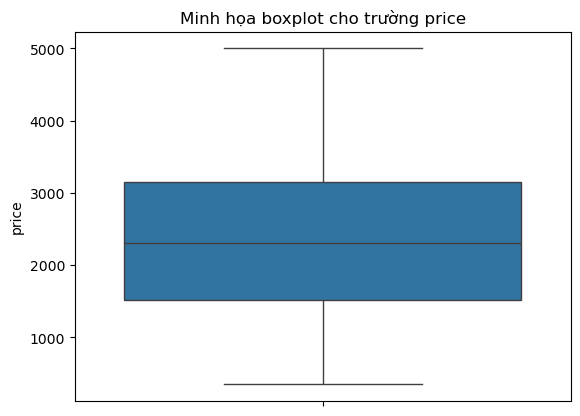

In [5]:
#Code for 'price' field
sns.boxplot(data=newdf,y='price')
plt.title("Minh họa boxplot cho trường price")
plt.show()

c:\Users\Lenovo\miniconda3\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


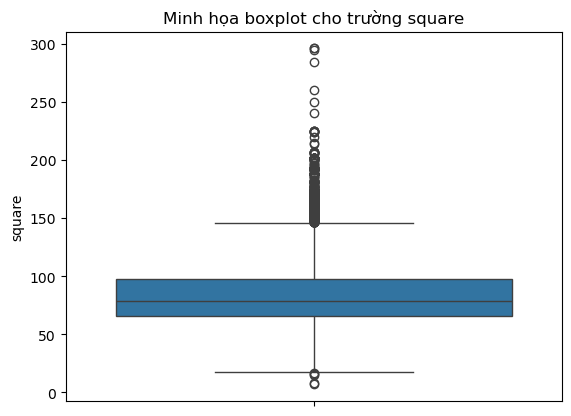

In [6]:
#Code for 'square' field
sns.boxplot(data=newdf,y='square')
plt.title("Minh họa boxplot cho trường square")
plt.show()

c:\Users\Lenovo\miniconda3\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


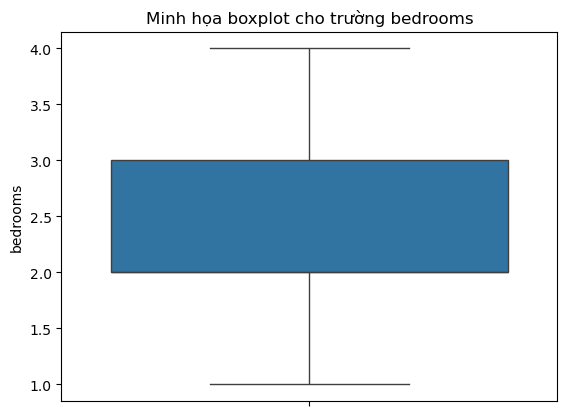

In [7]:
#Code for 'bedrooms' field
sns.boxplot(data=newdf,y='bedrooms')
plt.title("Minh họa boxplot cho trường bedrooms")
plt.show()

c:\Users\Lenovo\miniconda3\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


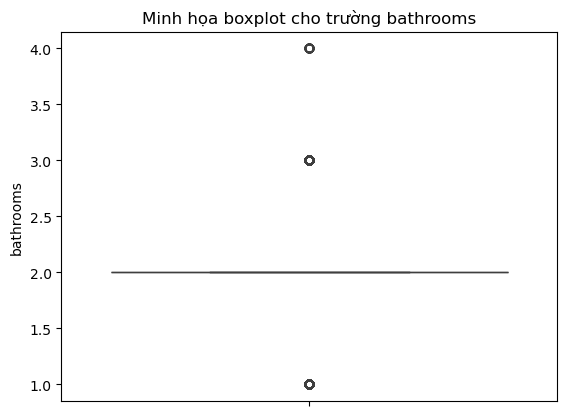

Counter({2.0: 67201, 1.0: 11154, 3.0: 2756, 4.0: 51, nan: 1})


In [8]:
#Code for 'bathrooms' field
sns.boxplot(data=newdf,y='bathrooms')
plt.title("Minh họa boxplot cho trường bathrooms")
plt.show()
from collections import Counter
x=newdf['bathrooms']
set=Counter(x)
print(set)

2. Cho đoạn code minh họa Biểu đồ thể hiện số bài đăng theo tháng của năm 2020. Hãy thực hiện các yêu cầu cho các câu hỏi dưới đây:

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23096\3073720224.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')


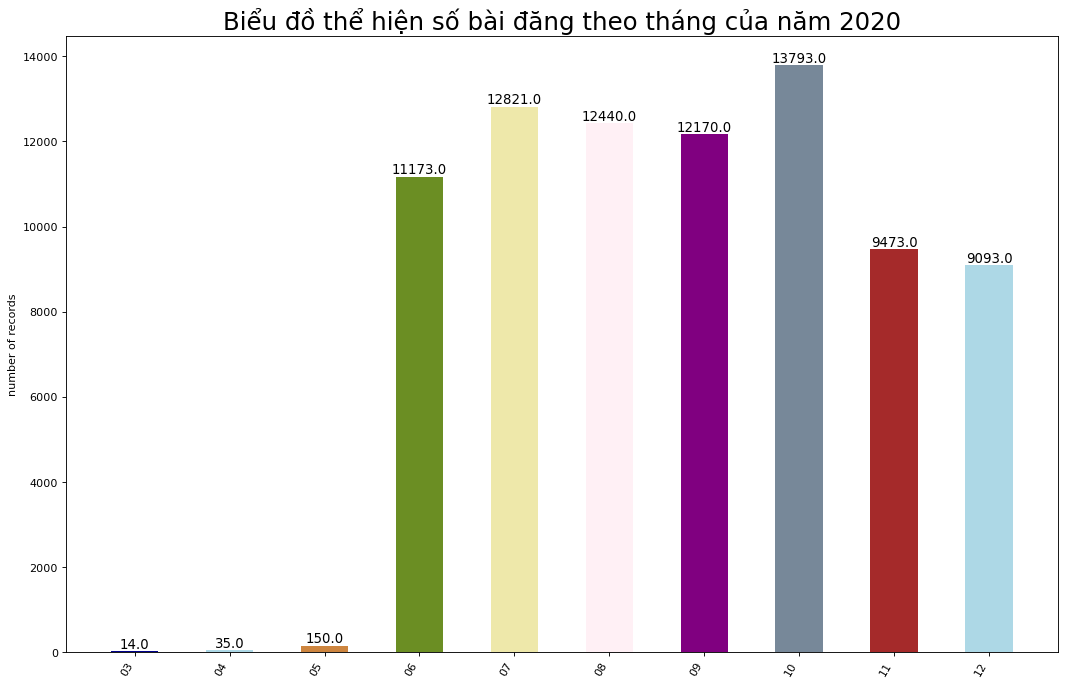

In [9]:
df1 = newdf.groupby('month').size().reset_index(name='number of records')
n = df1['month'].unique().__len__()+1
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)

plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df1['month'], df1['number of records'], color=c, width=.5)
for i, val in enumerate(df1['number of records'].values):
    plt.text(i,val, float(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':12})

plt.gca().set_xticklabels(df1['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ thể hiện số bài đăng theo tháng của năm 2020", fontsize=22)
plt.ylabel('number of records')
plt.show()

* Biểu đồ thể hiện giá nhà đất trung bình theo tháng (VND/m2)

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             10 non-null     string 
 1   price             10 non-null     float64
 2   square            10 non-null     float64
 3   price_per_square  10 non-null     float64
dtypes: float64(3), string(1)
memory usage: 452.0 bytes
  month         price     square  price_per_square
0    03  2.795900e+04     1062.0         26.326742
1    04  6.456900e+04     2763.0         23.369164
2    05  3.247642e+05    12122.0         26.791301
3    06  2.606593e+07   918144.0         28.389805
4    07  3.020493e+07  1060356.0         28.485648


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23096\573371925.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(df_price['month'], rotation=60, horizontalalignment= 'right')


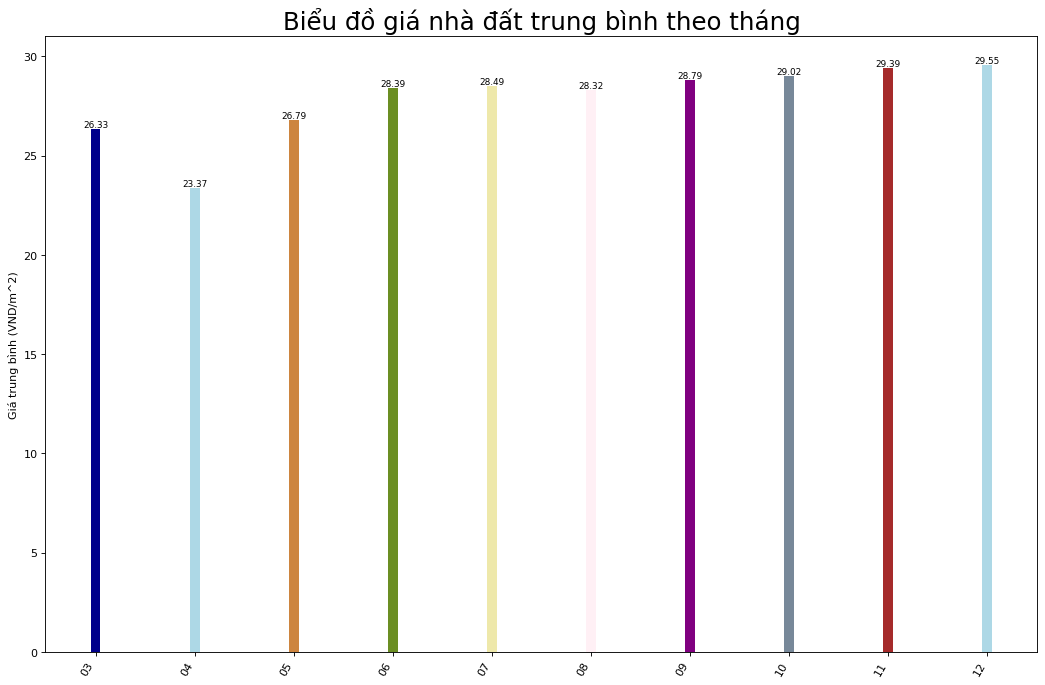

In [10]:
#Code ở đây
df1 = newdf.groupby('month')
df_price=df1[['price','square']].sum().reset_index()# Reset_index có tác dụng trở về thành một dạng dataframe bình thường có thể biểu diễn 
df_price['price_per_square']=df_price['price']/df_price['square']
df_price.info()
print(df_price.head())

n = df_price['month'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df_price['month'], df_price['price_per_square'], color=c, width=.1)
for i, val in enumerate(df_price['price_per_square'].values):
    plt.text(i,val, f"{val:.2f}", horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':8})

plt.gca().set_xticklabels(df_price['month'], rotation=60, horizontalalignment= 'right')
plt.title("Biểu đồ giá nhà đất trung bình theo tháng", fontsize=22)
plt.ylabel('Giá trung bình (VND/m^2)')
plt.show()

* Biểu đồ mật độ giá nhà của tháng 4 và tháng 12 (VND/m2)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23096\1378093683.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_april,label="April",color='red')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23096\1378093683.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_decem,label='December',color=

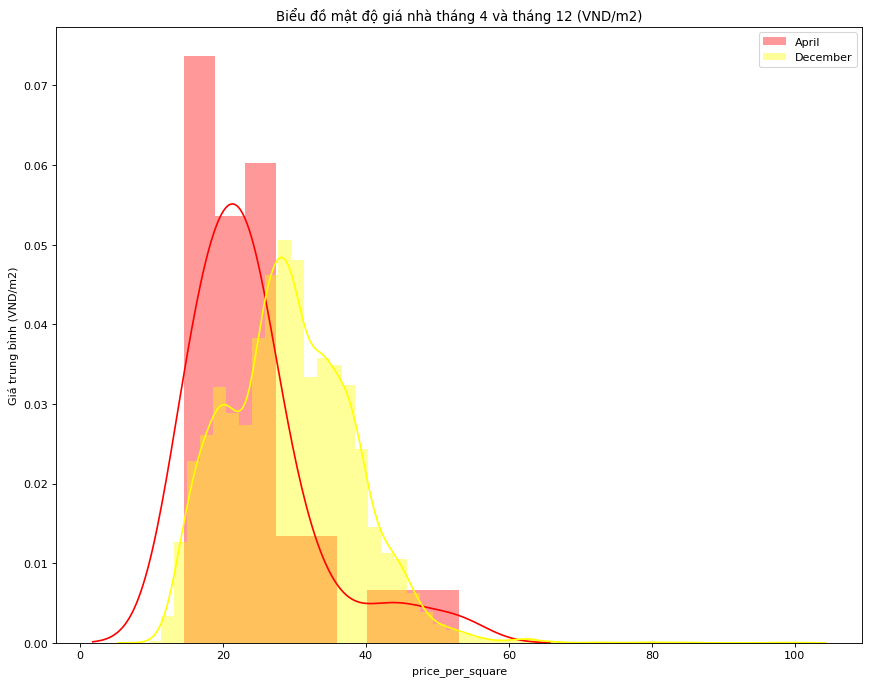

In [11]:
#Gọi ý: sns.distplot()
df=newdf.copy()
df['price_per_square']=df['price']/df['square']
df_april=df.loc[df['month']=='04','price_per_square']
df_decem=df.loc[df['month']=='12','price_per_square']
plt.figure(figsize=(13,10), dpi= 80)
sns.distplot(df_april,label="April",color='red')
sns.distplot(df_decem,label='December',color='Yellow')

plt.title("Biểu đồ mật độ giá nhà tháng 4 và tháng 12 (VND/m2)")
plt.ylabel("Giá trung bình (VND/m2)")
plt.legend()
plt.show()


* Số lượng bất động sản phân theo số lượng bedrooms

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bedrooms           4 non-null      float64
 1   number_of_records  4 non-null      int64  
dtypes: float64(1), int64(1)
memory usage: 196.0 bytes


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23096\541145801.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


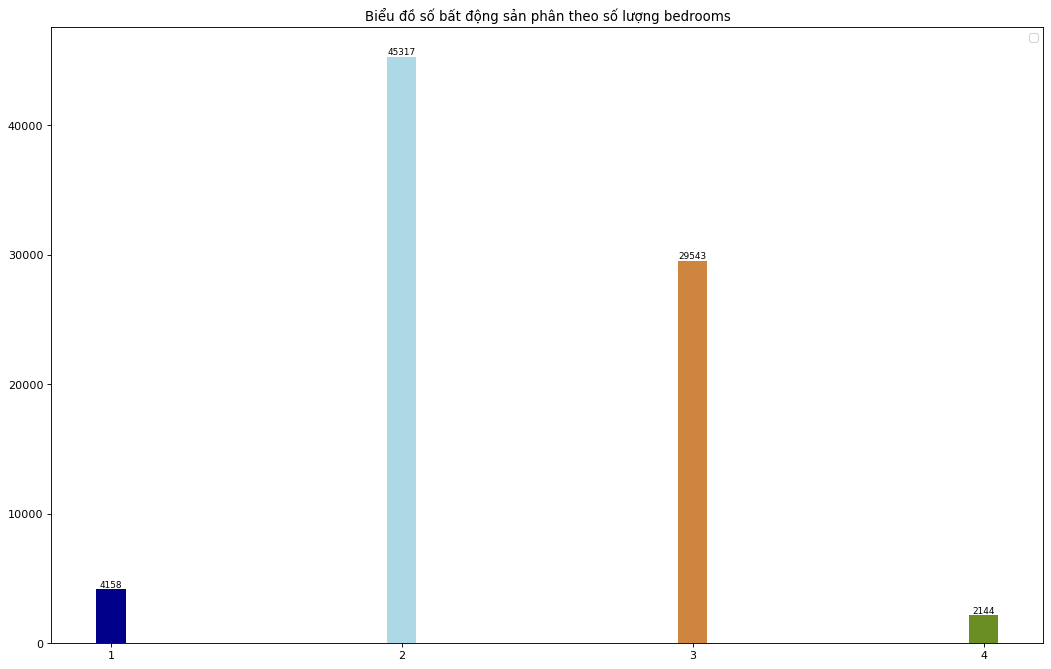

In [12]:
# Code ở đây
df2=newdf.groupby('bedrooms').size().reset_index(name="number_of_records")
df2.info()
n = df2['bedrooms'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.xticks(df2['bedrooms'])# Loại bỏ các giá trị .5
plt.bar(df2['bedrooms'], df2['number_of_records'], color=c, width=.1)
for i, val in enumerate(df2['number_of_records'].values):
    plt.text(df2['bedrooms'][i],val, int(val), horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':8})
plt.title("Biểu đồ số bất động sản phân theo số lượng bedrooms")
plt.legend()
plt.show()


* Giá bất động sản trung bình theo số lượng bedrooms

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bedrooms          4 non-null      float64
 1   price             4 non-null      float64
 2   square            4 non-null      float64
 3   price_per_square  4 non-null      float64
dtypes: float64(4)
memory usage: 260.0 bytes


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23096\1814539155.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


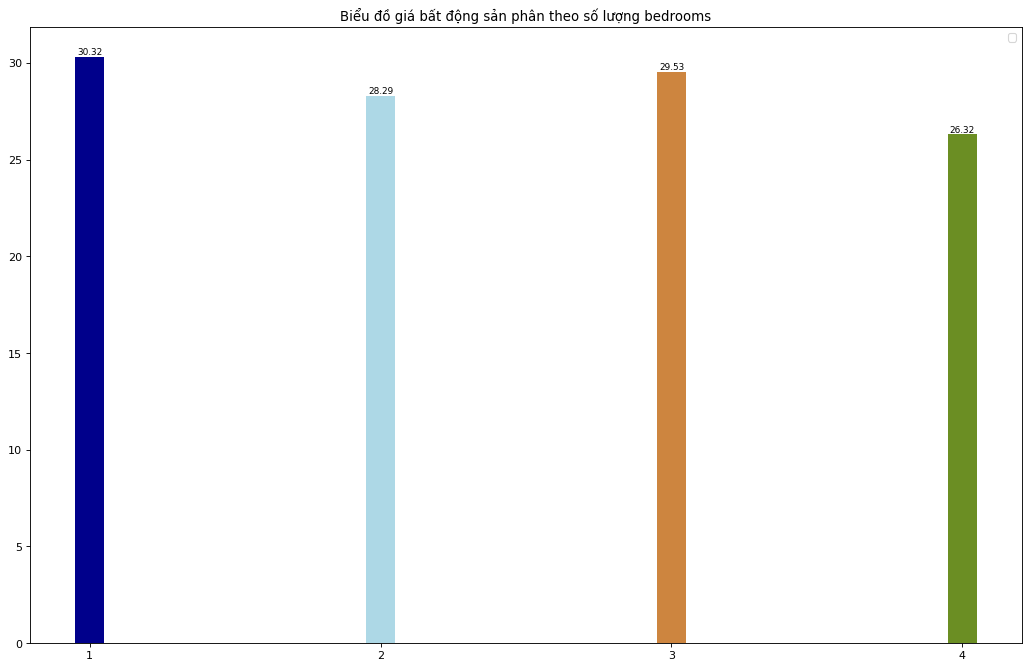

In [20]:
# Code ở đây
df3=newdf.groupby('bedrooms')
df3=df3[['price','square']].sum().reset_index()
df3['price_per_square']=df3['price']/df3['square']
df3.info()

n = df3['bedrooms'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.xticks(df3['bedrooms'])# Loại bỏ các giá trị .5
plt.bar(df3['bedrooms'], df3['price_per_square'], color=c, width=.1)
for i  in range (len(df3['bedrooms'])):
    plt.text(df3['bedrooms'][i],df3['price_per_square'][i],f"{df3['price_per_square'][i]:.2f}", horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':8})
plt.title("Biểu đồ giá bất động sản phân theo số lượng bedrooms")
plt.legend()
plt.show()





* Giá nhà đất trung bình theo quận (VND/m2)

<class 'pandas.DataFrame'>
Index: 23 entries, 11 to 16
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   district          23 non-null     str    
 1   price             23 non-null     float64
 2   square            23 non-null     float64
 3   price_per_square  23 non-null     float64
dtypes: float64(3), str(1)
memory usage: 920.0 bytes


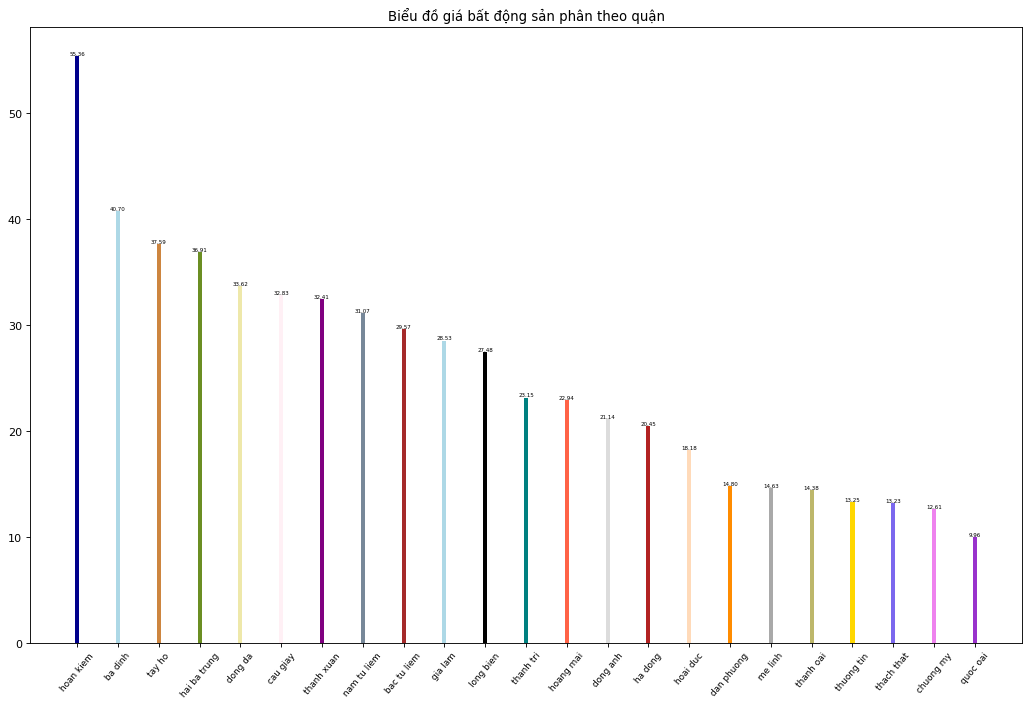

In [34]:
# Code ở đây
df4=newdf.groupby('district')
df4=df4[['price','square']].sum().reset_index()
df4['price_per_square']=df4['price']/df4['square']
df4=df4.sort_values(by='price_per_square',ascending=False)# Sort theo value theo chiều giảm dần
df4.info()

n = df4['district'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['district'], df4['price_per_square'], color=c, width=.1)
for i  in range (len(df4['district'])):
    plt.text(df4['district'][i],df4['price_per_square'][i],f"{df4['price_per_square'][i]:.2f}", horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':5})
plt.title("Biểu đồ giá bất động sản phân theo quận")
plt.xticks(rotation=50,fontsize=8)#Xoay các số và giảm font chữ
plt.show()

* Giá nhà đất trung bình theo các phường quận Hoàn Kiếm (VND/m2)

<class 'pandas.DataFrame'>
Index: 12 entries, 4 to 8
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ward              12 non-null     str    
 1   price             12 non-null     float64
 2   square            12 non-null     float64
 3   price_per_square  12 non-null     float64
dtypes: float64(3), str(1)
memory usage: 480.0 bytes


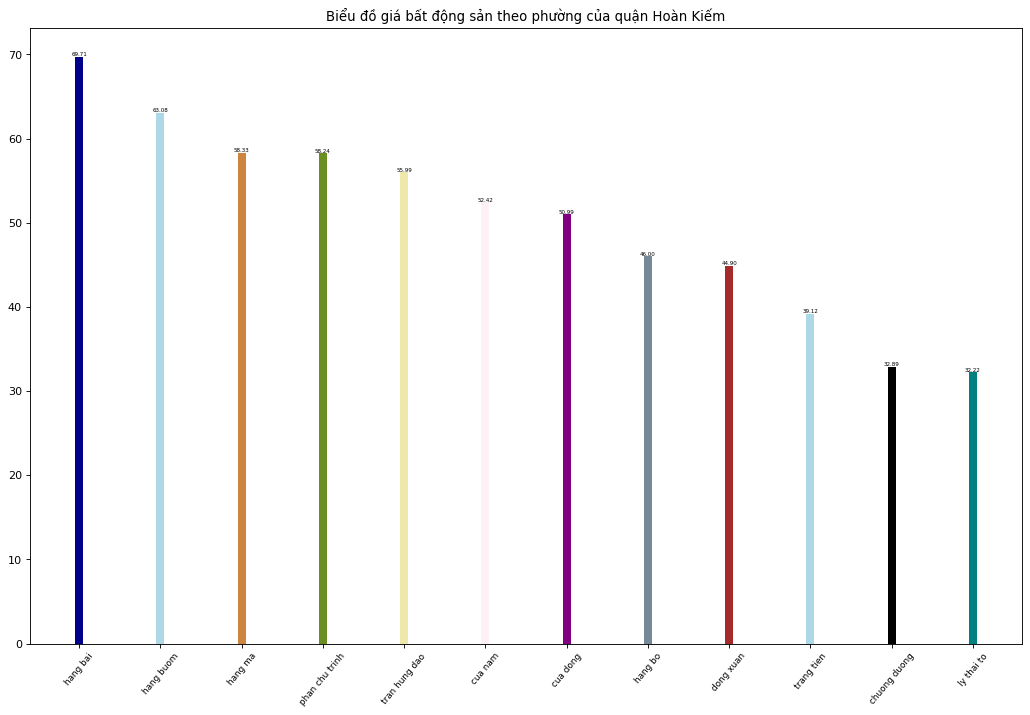

In [69]:
# Code ở đây
df4=(newdf.iloc[newdf['district']=='hoan kiem']).groupby('ward')
df4=df4[['price','square']].sum().reset_index()
df4['price_per_square']=df4['price']/df4['square']
df4=df4.sort_values(by='price_per_square',ascending=False)# Sort theo value theo chiều giảm dần
df4.info()

n = df4['ward'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['ward'], df4['price_per_square'], color=c, width=.1)
for i,val  in  enumerate(df4['price_per_square'].values):
    plt.text(i,val,f"{val:.2f}",horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':5})
plt.title("Biểu đồ giá bất động sản theo phường của quận Hoàn Kiếm")
plt.xticks(rotation=50,fontsize=8)#Xoay các số và giảm font chữ
plt.show()

* Giá nhà đất trung bình theo nhà đầu tư (VND/m2)

<class 'pandas.DataFrame'>
Index: 15 entries, 129 to 163
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   investor          15 non-null     str    
 1   price             15 non-null     float64
 2   square            15 non-null     float64
 3   price_per_square  15 non-null     float64
dtypes: float64(3), str(1)
memory usage: 600.0 bytes


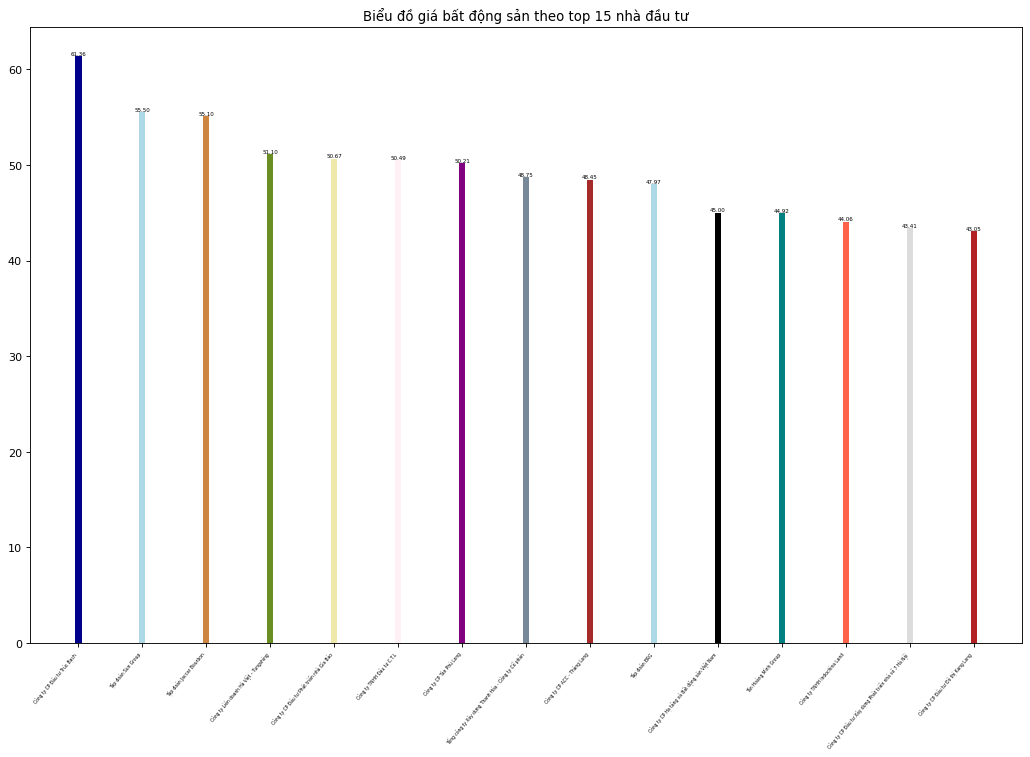

In [61]:
# Code ở đây
df4=newdf.groupby('investor')
df4=df4[['price','square']].sum().reset_index()
df4['price_per_square']=df4['price']/df4['square']
df4=df4.sort_values(by='price_per_square',ascending=False)# Sort theo value theo chiều giảm dần
df4=df4.head(15)#Chỉ lấy 15 nhà đầu tư cao nhất 
df4.info()

n = df4['investor'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['investor'], df4['price_per_square'], color=c, width=.1)
for i,val  in  enumerate(df4['price_per_square'].values):
    plt.text(df4['investor'].iloc[i],val,f"{val:.2f}",horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':5})
plt.title("Biểu đồ giá bất động sản theo top 15 nhà đầu tư")
plt.xticks(rotation=50,fontsize=4,horizontalalignment='right')#Xoay các số và giảm font chữ và nó bắt đầu từ bên phải cuối 
plt.show()

* Giá nhà đất trung bình theo dự án (VND/m2)

<class 'pandas.DataFrame'>
Index: 15 entries, 197 to 606
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   project           15 non-null     str    
 1   price             15 non-null     float64
 2   square            15 non-null     float64
 3   price_per_square  15 non-null     float64
dtypes: float64(3), str(1)
memory usage: 600.0 bytes


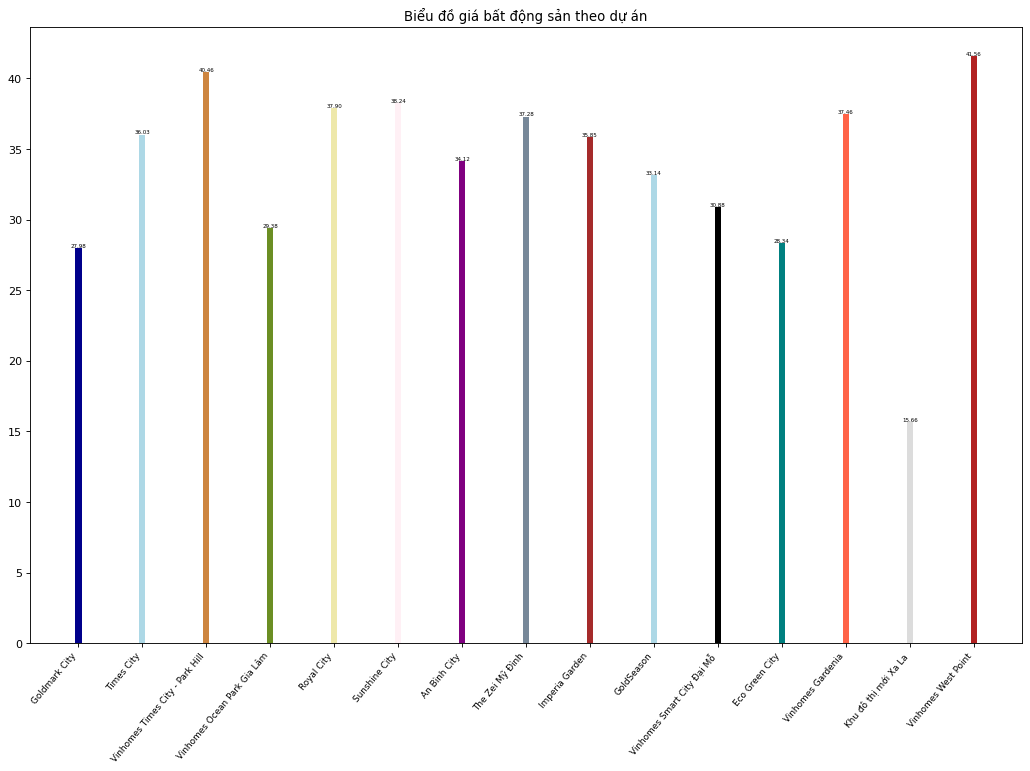

In [79]:
# Code ở đây
df4=newdf.groupby('project')
df4=df4[['price','square']].sum().reset_index()
df4['price_per_square']=df4['price']/df4['square']
df4=df4.sort_values(by='price',ascending=False)# Sort theo tổng số tiền của dự án theo chiều giảm dần
df4=df4.head(15)#Lại chỉ lấy 15 dự án lớn nhất
df4.info()

n = df4['project'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['project'], df4['price_per_square'], color=c, width=.1)
for i,val  in  enumerate(df4['price_per_square'].values):
    plt.text(i,val,f"{val:.2f}",horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':5})
plt.title("Biểu đồ giá bất động sản theo dự án")
plt.xticks(rotation=50,fontsize=8,horizontalalignment='right')#Xoay các số và giảm font chữ
plt.show()

* Giá bất động sản phân bố theo top 10 nhà đầu tư triệu /m2

<class 'pandas.DataFrame'>
Index: 15 entries, 129 to 163
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   investor          15 non-null     str    
 1   price             15 non-null     float64
 2   square            15 non-null     float64
 3   price_per_square  15 non-null     float64
dtypes: float64(3), str(1)
memory usage: 600.0 bytes


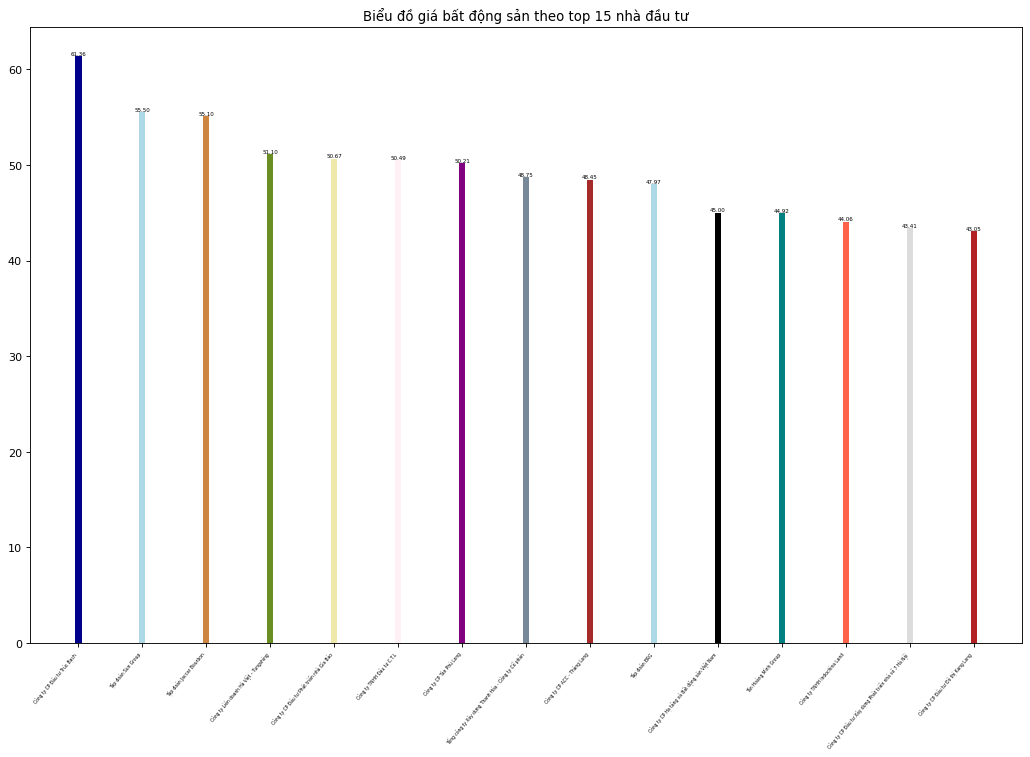

In [77]:
# Code ở đây
df4=newdf.groupby('investor')
df4=df4[['price','square']].sum().reset_index()
df4['price_per_square']=df4['price']/df4['square']
df4=df4.sort_values(by='price_per_square',ascending=False)# Sort theo value theo chiều giảm dần
df4=df4.head(15)#Chỉ lấy 15 nhà đầu tư cao nhất 
df4.info()

n = df4['investor'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['investor'], df4['price_per_square'], color=c, width=.1)
for i,val  in  enumerate(df4['price_per_square'].values):
    plt.text(df4['investor'].iloc[i],val,f"{val:.2f}",horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':5})
plt.title("Biểu đồ giá bất động sản theo top 15 nhà đầu tư")
plt.xticks(rotation=50,fontsize=4,horizontalalignment='right')#Xoay các số và giảm font chữ và nó bắt đầu từ bên phải cuối 
plt.show()

* Giá nhà đất trung bình theo hướng nhà (VND/m2)

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   direction         8 non-null      str    
 1   price             8 non-null      float64
 2   square            8 non-null      float64
 3   price_per_square  8 non-null      float64
dtypes: float64(3), str(1)
memory usage: 388.0 bytes


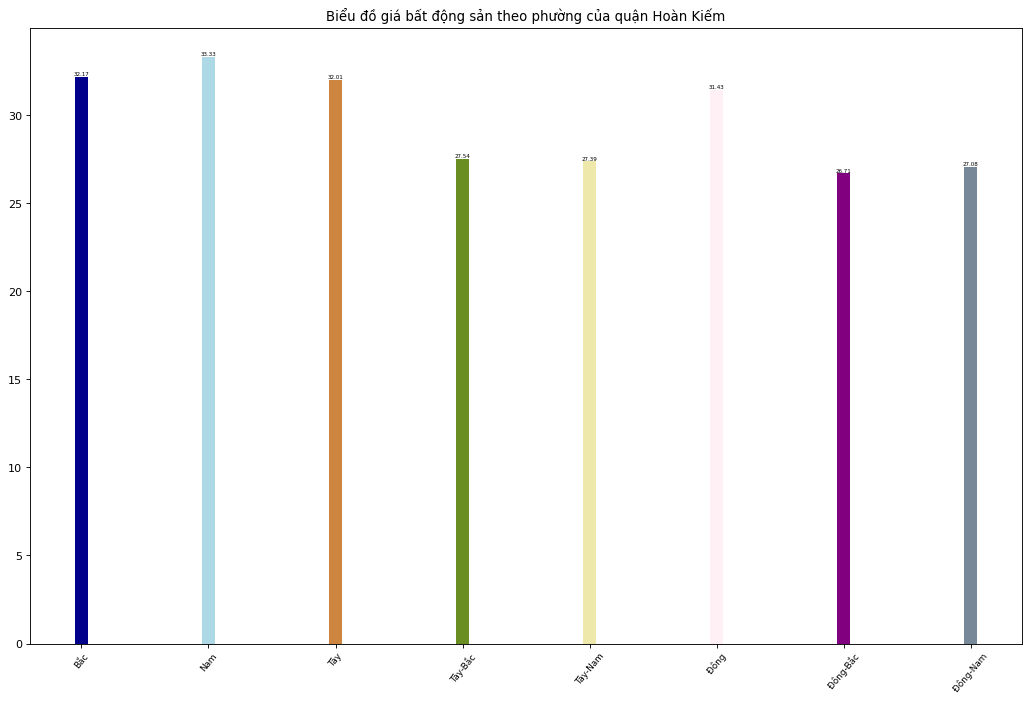

In [82]:
# Code ở đây
df4=newdf.groupby('direction')
df4=df4[['price','square']].sum().reset_index()
df4['price_per_square']=df4['price']/df4['square']
df4.info()

n = df4['direction'].unique().__len__()+1#Tạo các màu 
all_colors = list(plt.cm.colors.cnames.keys())
random.seed(100)
c = random.choices(all_colors, k=n)


plt.figure(figsize=(16,10), dpi= 80)
plt.bar(df4['direction'], df4['price_per_square'], color=c, width=.1)
for i,val  in  enumerate(df4['price_per_square'].values):
    plt.text(i,val,f"{val:.2f}",horizontalalignment='center', verticalalignment='bottom', fontdict={'fontweight':500, 'size':5})
plt.title("Biểu đồ giá bất động sản theo phường của quận Hoàn Kiếm")
plt.xticks(rotation=50,fontsize=8)#Xoay các số và giảm font chữ
plt.show()

3. Tương quan giữa các trường thuộc tính

* https://vi.wikipedia.org/wiki/H%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan
* bieu do the hien he so tuong quan giua cac cap bien so thuc banggf biểu đồ heatmap

Text(0.5, 1.0, 'Biểu đồ hệ số tương quan ')

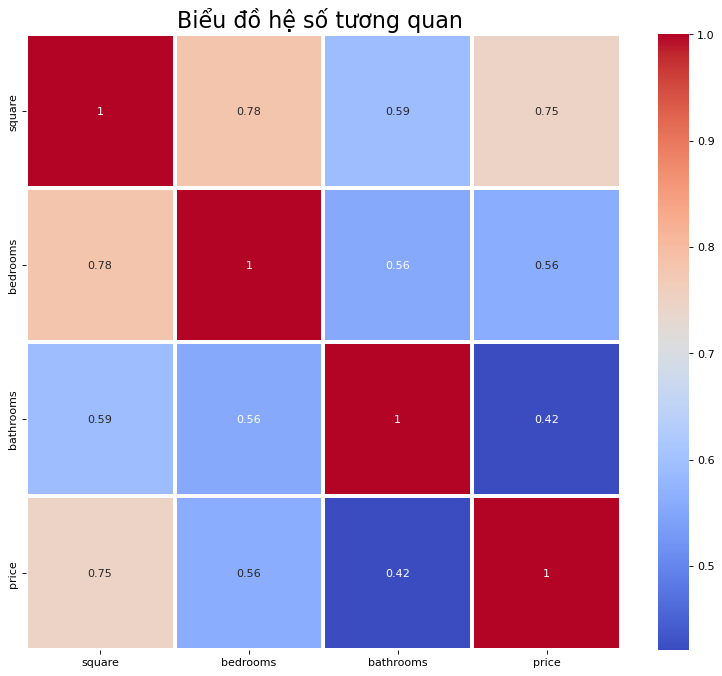

In [88]:
# Gợi ý: sns.heatmap(cmap='RdYlGn', ...)
plt.figure(figsize=(12,10), dpi= 80)
data=newdf.corr(numeric_only=True)
sns.heatmap(data,annot=True, cmap='coolwarm', linewidths=2)
plt.title("Biểu đồ hệ số tương quan ",fontsize=20)


* bieu do the hien moi quan he giua cac bien so thuc với biểu đồ phân tán

<class 'pandas.DataFrame'>
RangeIndex: 81163 entries, 0 to 81162
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         81163 non-null  string 
 1   month      81162 non-null  string 
 2   project    78097 non-null  str    
 3   investor   65453 non-null  str    
 4   square     81162 non-null  float64
 5   bedrooms   81162 non-null  float64
 6   bathrooms  81162 non-null  float64
 7   direction  51086 non-null  str    
 8   balcony    54426 non-null  str    
 9   district   81162 non-null  str    
 10  ward       79506 non-null  str    
 11  price      81162 non-null  float64
dtypes: float64(4), str(6), string(2)
memory usage: 7.4 MB


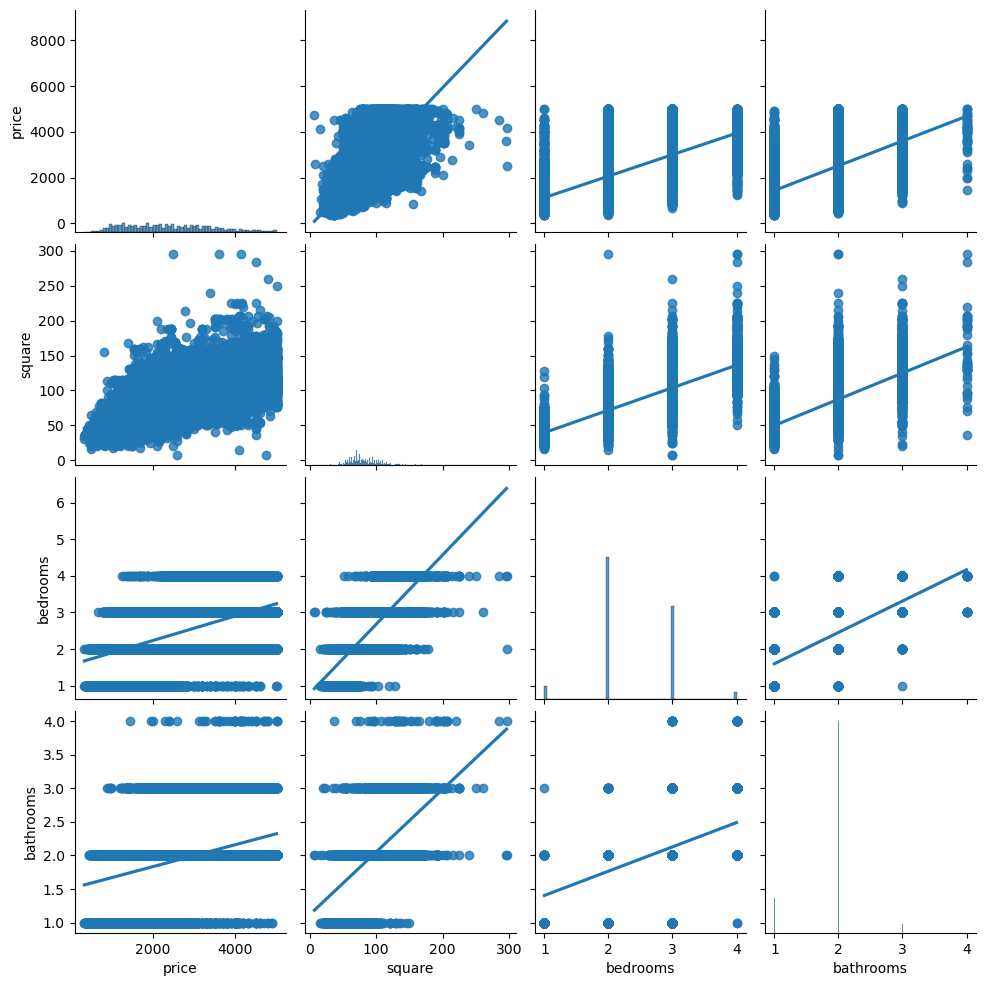

In [99]:
#Gợi ý: sns.pairplot(kind='scatter', ...)
newdf.info()
sns.pairplot(newdf[['price', 'square', 'bedrooms', 'bathrooms']], kind='reg')

4. Mật độ giá nhà trung bình theo quận 

(0.0, 100.0)

<Figure size 7500x4000 with 0 Axes>

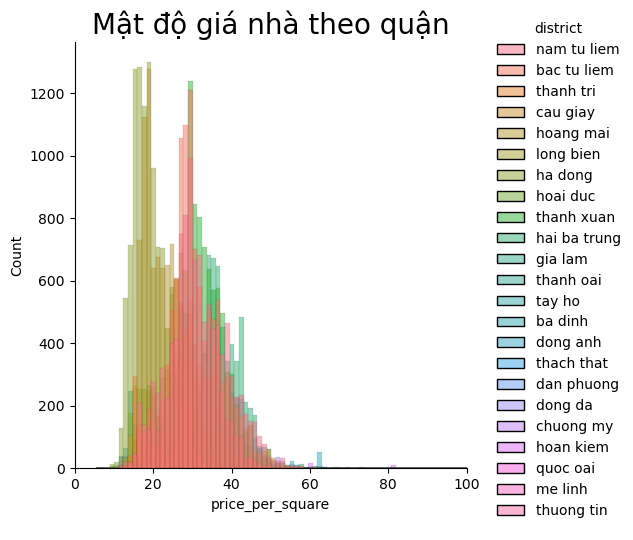

In [4]:
#Gợi ý: sns.displot()
df5=newdf.copy()
df5['price_per_square']=df5['price']/df5['square']
plt.figure(figsize=(150,80),dpi=50)
sns.displot(data=df5,x='price_per_square',hue='district')#Hue là cái để phân biệt ra 
plt.title("Mật độ giá nhà theo quận",fontsize=20)
plt.xlim(0,100)#Chỉ xem dải từ 0->100

End :))